In [8]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt
import json


In [12]:
#%pip install -e ..

In [9]:
from proj2dhullsampler.pipeline import build_case, default_worker_count

In [10]:
with open('apply_config.json', 'r') as file:
    config = json.load(file)

In [11]:
config

{'mode': 'python',
 'working_dir': '/glade/work/qingyuany/repo_data/',
 'case_name': 'proj2d_example_original_ppe3',
 'result_name': 'sample1',
 'data_paths': {'obs_nc': '/glade/u/home/qingyuany/repos/spatialtuning/data/nc_based_data/interpolated_obs.nc',
  'obs_tab': None,
  'para': '/glade/work/qingyuany/camml_re/v0/parameter_34_100.csv',
  'ppe_nc': '/glade/work/qingyuany/camml_re/v0/initial_ppe.nc',
  'ppe_tab': None},
 'obs_dict': {'SWCF': 'swcrf_toa',
  'LWCF': 'lwcrf_toa',
  'TMQ': 'pwv',
  'FLUT': 'olr',
  'PRECT': 'pr',
  'FSNTOA': 'swabs_toa'},
 'lat_bins': {'start': -75, 'stop': 75, 'step': 5},
 'manual_regions': [{'nm': 'PRECT',
   'lat_min': 4,
   'lat_max': 7,
   'lon_min': 1,
   'lon_max': 359},
  {'nm': 'SWCF', 'lat_min': 4, 'lat_max': 7, 'lon_min': 1, 'lon_max': 359}],
 'n_sample': 100000,
 'prepare_case': {'n_cpus': 6, 'threshold_levels': [2.0]},
 'threshold_level': 2.0,
 'emultor_error_ratio_threshold': 0.2,
 'visualize_check_vars': ['SWCF_zonal_30to40'],
 'vars_to_d

In [12]:
working_dir = config["working_dir"]
case_name = config["case_name"]
result_name = config["result_name"]

In [19]:
# Loads data per config["data_paths"], then either creates+prepares a new
# case or loads an existing one from working_dir/case_name - same logic
# run_apply.py uses for batch (PBS) runs, so both stay in sync automatically.
# mode="notebook" (rather than config["mode"]) so figures show inline here
# regardless of what mode the batch config was written for.
test_case = build_case(config, mode="notebook")

Worker count: prepare_case.n_cpus=6 (job allocation reports 16 CPUs available; an explicit config value, if set, takes precedence)
Case directory already exists; loading it instead of re-preparing.
<class 'pandas.core.frame.DataFrame'>
                          0
SWCF_zonal_-75to-70    0.01
SWCF_zonal_-70to-65    0.01
SWCF_zonal_-65to-60    0.01
SWCF_zonal_-60to-55    0.05
SWCF_zonal_-55to-50    0.02
...                     ...
FSNTOA_zonal_55to60    0.01
FSNTOA_zonal_60to65    0.02
FSNTOA_zonal_65to70    0.03
local_PRECT_4_7_1_359  0.03
local_SWCF_4_7_1_359   0.05

[176 rows x 1 columns]


In [20]:
vars_to_drop = config["vars_to_drop"]
emultor_error_ratio_threshold = config["emultor_error_ratio_threshold"]
n_survive_threshold = config["n_survive_threshold"]
n_survive_threshold_2d = config["n_survive_threshold_2d"]
added_num = config["added_number_for_pairs"]
n_var_thre = config["n_var_thre"]
max_workers = config.get("max_workers", default_worker_count())
n_pts = config["n_pts"]
n_threshold = config["n_threshold"]
sample_threshold = config["sample_threshold"]
n_max = config["n_max"]
top_n = config["top_n"]

In [21]:
test_case.drop_by_name(vars_to_drop)
test_case.drop_by_emulator_performance(emultor_error_ratio_threshold)
test_case.drop_by_n_survive(n_survive_threshold)

Drop variables [] based on hand selection
Drop variables [] based on emulator perfornace (error ratio of 0.2 as threshold)
Drop variables ['FSNTOA_zonal_-40to-35', 'SWCF_zonal_-30to-25', 'PRECT_zonal_15to20', 'SWCF_zonal_-40to-35', 'PRECT_zonal_20to25', 'SWCF_zonal_35to40', 'PRECT_zonal_-60to-55', 'SWCF_zonal_30to35', 'FSNTOA_zonal_-30to-25', 'SWCF_zonal_-35to-30', 'FSNTOA_zonal_-35to-30', 'FSNTOA_zonal_30to35', 'PRECT_zonal_-25to-20'] because they do not help constrain the parameters
Drop variables ['PRECT_zonal_-75to-70', 'SWCF_zonal_-70to-65', 'PRECT_zonal_-70to-65', 'SWCF_zonal_-75to-70'] because they constrain the parmaeters too much


In [22]:
test_case.remove_var2d_auto(n_survive_threshold_2d, added_num=added_num)
test_case.drop_by_nvar_per_pair(n_var_thre)

micro_mg_vtrmi_factor                    and micro_mg_dcs                            :        0
microp_aero_wsub_scale                   and microp_aero_npccn_scale                 :     3646
There are 2 groups that have no overlapping within own groups
Drop variable ['LWCF_zonal_-75to-70']
micro_mg_vtrmi_factor                    and micro_mg_dcs                            :        2
microp_aero_wsub_scale                   and microp_aero_npccn_scale                 :     3646
There are 2 groups that have no overlapping within own groups
Drop variable ['PRECT_zonal_10to15']
microp_aero_wsub_scale                   and microp_aero_npccn_scale                 :     3646
There are 1 groups that have no overlapping within own groups
Drop variable ['FSNTOA_zonal_-75to-70']
There are 0 groups that have no overlapping within own groups
No non-overlapping variables at this stage for the variables sharing the same 2 sensitive parameters
Finished dropping variables
Drop variables [] because wh

In [ ]:
test_case.prepare_for_sampling(n_pts=n_pts, n_threshold=n_threshold, sample_threshold=sample_threshold, max_workers=max_workers)
test_case.draw(n_pts=n_pts, n_threshold=n_threshold, sample_threshold=sample_threshold, max_workers=max_workers, n_max=n_max)

In [24]:
test_case.save_samples_specifications(result_name, top_n = top_n)

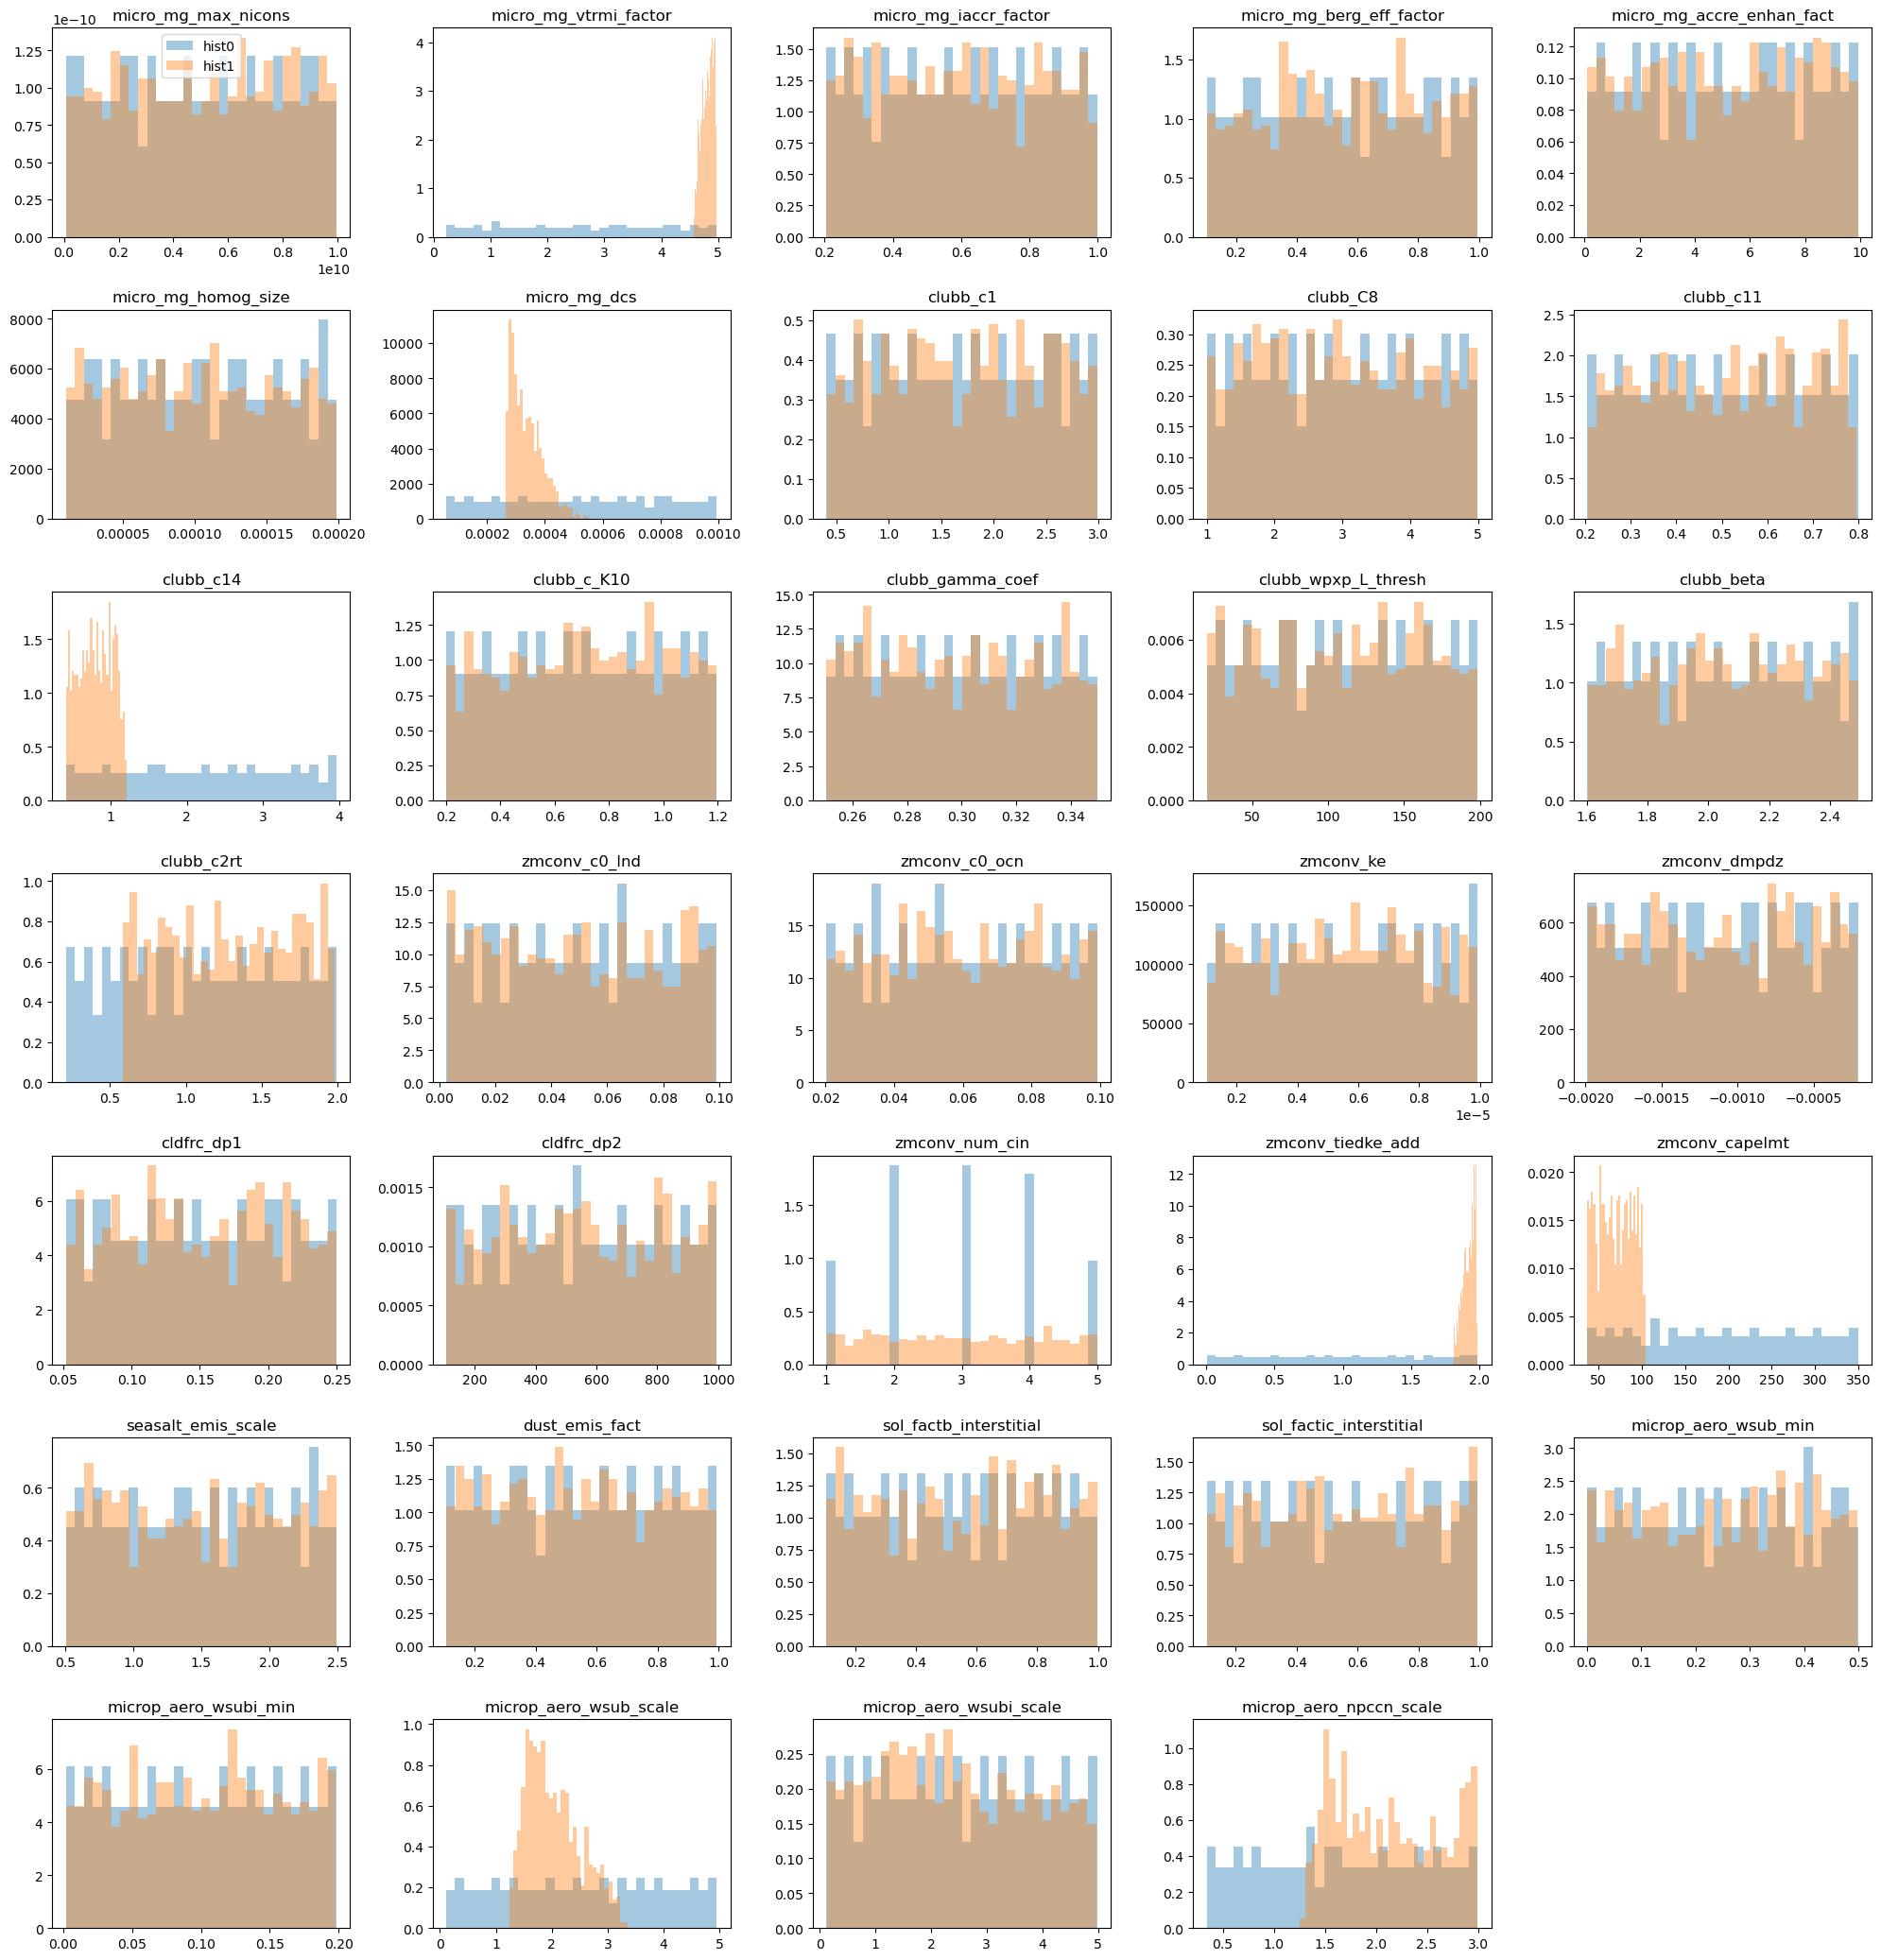

In [25]:
test_case.compare_with_original()

In [26]:
(test_case.results.unscaled_samples.max() - test_case.results.unscaled_samples.min()).prod()

2.2632471381099342e-05